In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [5]:
# system parameters
m = 1.0
c = 0.5
k = 4.0

a1 = -k/m
a2 = -c/m
b1 = 1/m

print(f"a1 = {a1}, a2 ={a2}, b1 = {b1}")

a1 = -4.0, a2 =-0.5, b1 = 1.0


In [6]:
def F(t):
    u = 0.25 * np.random.randn()
    return u

In [7]:
def mass_spring_damp(t, state):
    # x(state) = x1, x1_dot
    x, x_dot, _ = state
    # m*x_ddot + c*x_dot + k*x = F (x = mass displacement)
    u = F(t)
    x_ddot = 1/m * (u - c * x_dot - k * x)
    return [x_dot, x_ddot, u]

In [17]:
# setup simulation parameters
t_span = (0, 10)
t = np.linspace(t_span[0], t_span[1], 1000)
x0 = [0.0, 0.0, 0] # 1m, 0m/s

sol = solve_ivp(mass_spring_damp, t_span, x0, t_eval=t)

fs = 100 #Hz - sampling freqency
sol_freq = np.fft.fftfreq(len(t), 1/fs)
sol_out_fft = np.fft.fft(sol.y[0])
sol_in_fft = np.fft.fft(sol.y[2])

# take real parts from signal
half_n = len(t)//2
fft_freq = sol_freq[:half_n]
sol_out_fft_mag = 1 / half_n * np.abs(sol_out_fft[:half_n])

# plotting tf
sol_tf = sol_out_fft / sol_in_fft
sol_tf_mag = 1/half_n * np.abs(sol_tf[:half_n])

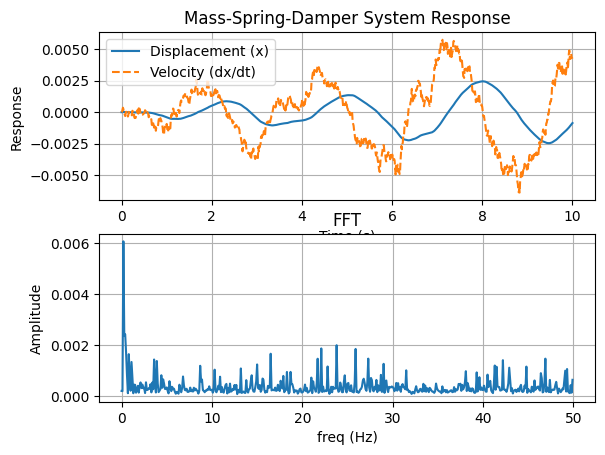

In [18]:
# view dynamics response and fft
plt.subplot(2,1,1)
plt.plot(sol.t, sol.y[0], label='Displacement (x)')
plt.plot(sol.t, sol.y[1], label='Velocity (dx/dt)', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.title('Mass-Spring-Damper System Response')
plt.legend()
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(fft_freq, sol_tf_mag)
plt.title('FFT')
plt.xlabel('freq (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

In [ ]:
# Build Regressor

# m*xdd + c*xd + k*x = F
# x = y and F = u
# m*y(t-2) + c * y(t-1) + k * y(t) = u
# y(t) = 1/k * (u(t) - m*y(t-2) - c * y(t-1)) , a2 = -m/k, a1 = -c/k

Phi = list() # regressor matrix
Y = list() # output vector

for t in range(2, len(sol.t)):
    Phi.append([sol.y[0][t-1], sol.y[0][t-2], sol.y[2][t]]) # a1, a2, b1
    Y.append(sol.y[0][t])


In [23]:
# least squares optimization
Phi = np.array(Phi)
Y = np.array(Y)

theta_hat, _, _, _ = np.linalg.lstsq(Phi, Y, rcond=None)
a1_hat, a2_hat, b1_hat = theta_hat

print("Actual Parameters")
print(f"a1 = {a1}, a2 ={a2}, b1 = {b1}")

print("Estimated Parameters:")
print(f"a1 = {a1_hat:.3f}, a2 = {a2_hat:.3f}, b1 = {b1_hat:.4f}")


Actual Parameters
a1 = -4.0, a2 =-0.5, b1 = 1.0
Estimated Parameters:
a1 = 1.999, a2 = -0.999, b1 = -0.0000


In [21]:
# parameter back tracking
k_hat = 1/b1_hat
m_hat = a2_hat*-1*k_hat
c_hat = a1_hat*-1*k_hat

print(f"k_hat = {k_hat:.3f}, m_hat = {m_hat:.3f}, c_hat = {c_hat:.3f}")

k_hat = -54223.015, m_hat = -54164.502, c_hat = 108366.224


Estimated Parameters:
a1 = 0.711, a2 = -0.203, b1 = 0.503


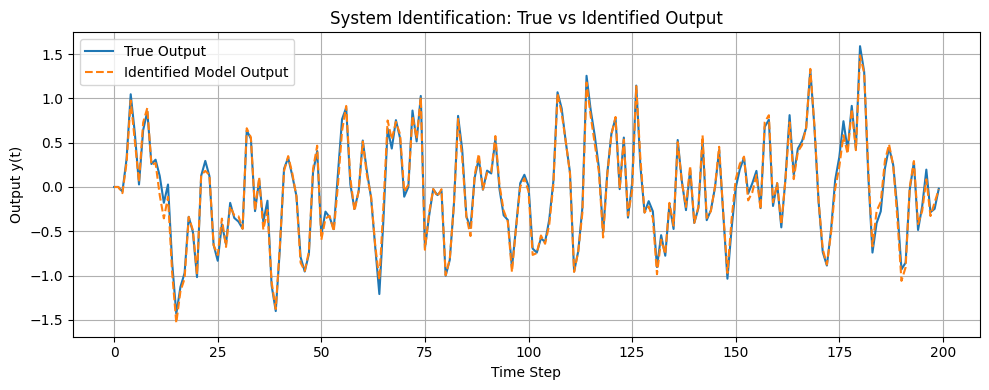

In [2]:
# chat gpt code

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

# -------------------------
# Step 1: Simulate Data
# -------------------------
np.random.seed(42)

# True system: y(t) = 0.7*y(t-1) - 0.2*y(t-2) + 0.5*u(t-1)
N = 200  # number of time steps
u = np.random.randn(N)  # random input
y = np.zeros(N)

# Simulate true output with some noise
for t in range(2, N):
    y[t] = 0.7 * y[t-1] - 0.2 * y[t-2] + 0.5 * u[t-1] + 0.05 * np.random.randn()

# -------------------------
# Step 2: Build Regressor Matrix for ARX(n=2, m=1)
# y(t) = a1*y(t-1) + a2*y(t-2) + b1*u(t-1)
# -------------------------
Phi = []  # regressor matrix
Y = []    # output vector

for t in range(2, N):
    Phi.append([y[t-1], y[t-2], u[t-1]])  # [a1, a2, b1]
    Y.append(y[t])

Phi = np.array(Phi)
Y = np.array(Y)

# -------------------------
# Step 3: Least Squares Estimation
# -------------------------
theta_hat, _, _, _ = lstsq(Phi, Y, rcond=None)
a1_hat, a2_hat, b1_hat = theta_hat

print("Estimated Parameters:")
print(f"a1 = {a1_hat:.3f}, a2 = {a2_hat:.3f}, b1 = {b1_hat:.3f}")

# -------------------------
# Step 4: Simulate Identified Model
# -------------------------
y_hat = np.zeros(N)
for t in range(2, N):
    y_hat[t] = a1_hat * y_hat[t-1] + a2_hat * y_hat[t-2] + b1_hat * u[t-1]

# -------------------------
# Step 5: Plot and Compare
# -------------------------
plt.figure(figsize=(10, 4))
plt.plot(y, label='True Output')
plt.plot(y_hat, '--', label='Identified Model Output')
plt.xlabel('Time Step')
plt.ylabel('Output y(t)')
plt.legend()
plt.title('System Identification: True vs Identified Output')
plt.grid()
plt.tight_layout()
plt.show()


In [24]:
from scipy.signal import welch, csd, TransferFunction
from scipy import signal

# Assuming x is input data and y is output data
#fs = 100  # Sampling frequency
x = sol.y[2]
y = sol.y[0]

f, pxx = welch(x, fs=fs)
f, pxy = csd(x, y, fs=fs)

h = pxy / pxx  # Transfer function

# Represent as a transfer function object
tf = TransferFunction(np.real(h), np.array([1]), dt=1/fs)

w, mag, phase = signal.dbode(tf)


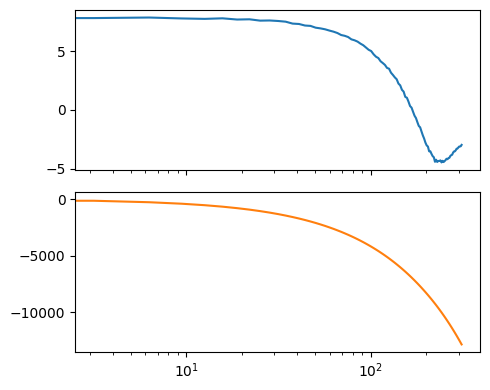

In [25]:
fg, (ax0, ax1) = plt.subplots(2, 1, sharex='all', figsize=(5, 4),
                              tight_layout=True)
ax0.semilogx(w, mag, 'C0-', label=r"$20\,\log_{10}|G(f)|$")  # Magnitude plot
ax1.semilogx(w, phase, 'C1-', label=r"$\angle G(f)$")  # Phase plot

In [26]:
tf.to_zpk()

ZerosPolesGainDiscrete(
array([ 0.94240371+0.j        ,  0.94825067+0.04165017j,
        0.94825067-0.04165017j,  0.94654857+0.09151419j,
        0.94654857-0.09151419j,  0.94260006+0.137061j  ,
        0.94260006-0.137061j  ,  0.93663523+0.18804565j,
        0.93663523-0.18804565j,  0.92163136+0.23804262j,
        0.92163136-0.23804262j,  0.90173558+0.27684387j,
        0.90173558-0.27684387j,  0.8943463 +0.31494437j,
        0.8943463 -0.31494437j,  0.88323726+0.36342838j,
        0.88323726-0.36342838j,  0.8629916 +0.41060573j,
        0.8629916 -0.41060573j,  0.84002074+0.45468109j,
        0.84002074-0.45468109j,  0.81371647+0.49786015j,
        0.81371647-0.49786015j,  0.77610843+0.53847654j,
        0.77610843-0.53847654j,  0.74273331+0.60163681j,
        0.74273331-0.60163681j,  0.75871485+0.54889219j,
        0.75871485-0.54889219j,  0.70937261+0.64318044j,
        0.70937261-0.64318044j,  0.67318901+0.67919726j,
        0.67318901-0.67919726j,  0.63739434+0.70922454j,
       